# 01 — บันได β: OLS vs TLS vs Rolling vs Kalman

โน้ตบุ๊กนี้คู่กับ **Part I** ของหนังสือ (`practice-part1.html`) — ทดสอบข้อเคลมทางเทคนิคหลัก 3 ข้อด้วยโค้ดจริง แทนที่จะเชื่อลอย ๆ:

1. OLS บน **ราคา** (cointegration) ดีเกินคาด (super-consistency) แม้ราคาจะมี noise
2. OLS บน **ผลตอบแทน** (return) มี attenuation bias จริง (EIV) — และ TLS ช่วยแก้ได้ถ้าเดา δ ถูก
3. เมื่อ β จริงเปลี่ยนตามเวลา — Rolling OLS กับ Kalman ตามได้ดีแค่ไหน (RMSE เทียบ β จริง)

**⚠️ เรื่องข้อมูล:** สภาพแวดล้อมรันโน้ตบุ๊กนี้ (sandbox) บล็อกการเชื่อมต่อไปยัง data provider ทางการเงินทุกเจ้า (Yahoo Finance, Stooq ฯลฯ — นโยบาย network ของ environment นี้) เราจึงใช้ **ข้อมูลจำลอง (simulated) ที่รู้ ground truth แน่นอน** แทน (`simdata.py`) ซึ่งจริง ๆ แล้ว *ดีกว่า* สำหรับการทดสอบ estimator เพราะเรารู้ β จริงและวัด bias ได้ตรง ๆ — ราคาจริงไม่มีวันให้ ground truth แบบนี้ ถ้าอยากรันกับข้อมูลจริง แค่เปลี่ยนฟังก์ชัน `load_prices()` เป็นตัวดึงราคาของคุณเอง โค้ดส่วน estimator ไม่สนใจที่มาของราคา


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pykalman import KalmanFilter
from simdata import simulate_cointegrated_pair

pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)


## Experiment A — β คงที่: OLS(price) vs OLS(return) vs TLS(return)

จำลองคู่ A/B ที่ cointegrate กันจริง โดย **β จริงคงที่ = 1.30** และราคาที่สังเกตได้ (observed) มี noise ปนทั้งสองขา (จำลอง bid-ask / microstructure noise) — นี่คือเงื่อนไขที่ทำให้เกิด attenuation bias ใน return-regression


In [2]:
df_a = simulate_cointegrated_pair(n=1500, beta_true=1.30, beta_drift="const",
                                   obs_noise_a=0.6, obs_noise_b=0.6, seed=42)

# --- 1. OLS on PRICE LEVELS (cointegration-style) ---
X_price = sm.add_constant(df_a["B_obs"])
ols_price = sm.OLS(df_a["A_obs"], X_price).fit()
beta_ols_price = ols_price.params["B_obs"]

# --- 2. OLS on RETURNS (return-regression-style) ---
ret_a = df_a["A_obs"].diff().dropna()
ret_b = df_a["B_obs"].diff().dropna()
X_ret = sm.add_constant(ret_b)
ols_ret = sm.OLS(ret_a, X_ret).fit()
beta_ols_return = ols_ret.params["B_obs"]

# --- 3. TLS / Deming on RETURNS, assuming delta=1 (equal noise both sides) ---
def tls_beta(x, y, delta=1.0):
    """Total least squares slope: eigenvector of the (scaled) covariance matrix.
    delta = ratio of noise-variance(y)/noise-variance(x); delta=1 is orthogonal TLS."""
    x = np.asarray(x); y = np.asarray(y)
    Sxx = np.var(x, ddof=1); Syy = np.var(y, ddof=1); Sxy = np.cov(x, y, ddof=1)[0, 1]
    # classic Deming formula
    num = (Syy - delta * Sxx) + np.sqrt((Syy - delta * Sxx) ** 2 + 4 * delta * Sxy ** 2)
    return num / (2 * Sxy)

beta_tls_return = tls_beta(ret_b.values, ret_a.values, delta=1.0)

bias_price  = abs(beta_ols_price  - 1.30)
bias_return = abs(beta_ols_return - 1.30)
print(f"True beta                          : 1.3000")
print(f"OLS on PRICE  (cointegration-style) : {beta_ols_price:.4f}   |bias| = {bias_price:.4f}")
print(f"OLS on RETURN (naive)               : {beta_ols_return:.4f}   |bias| = {bias_return:.4f}   ({bias_return/bias_price:.1f}x worse than price-OLS)")
print(f"TLS  on RETURN (delta=1)            : {beta_tls_return:.4f}   |bias| = {abs(beta_tls_return - 1.30):.4f}")


True beta                          : 1.3000
OLS on PRICE  (cointegration-style) : 1.2075   |bias| = 0.0925
OLS on RETURN (naive)               : 0.6760   |bias| = 0.6240   (6.7x worse than price-OLS)
TLS  on RETURN (delta=1)            : 1.7642   |bias| = 0.4642


### ผลที่ได้จริง (จากรันด้านบน, seed=42) — อ่านตรงนี้หลังรันเซลล์แล้ว

จากตัวเลขที่พิมพ์ออกมา:

- **OLS บนราคา (≈1.21 vs true 1.30)** ใกล้ความจริงกว่า **OLS บนผลตอบแทน (≈0.68 vs true 1.30) หลายเท่า** — bias ของ return-regression หนักกว่า price-regression ชัดเจน แม้ทั้งคู่เจอ noise ชุดเดียวกัน · นี่คือ **super-consistency** ที่ Part I §1.3 พูดถึง: ยิ่งข้อมูลราคายาว (I(1)) ยิ่งกลบ noise ได้เร็วกว่าที่ return (I(0)) กลบได้ — ลองเพิ่ม `n=` ในเซลล์บนเป็น 5000 แล้วรันซ้ำ จะเห็น bias ของราคายิ่งเล็กลงอีก ขณะที่ของ return ไม่ลดตามสัดส่วนเดียวกัน
- **TLS บนผลตอบแทน (δ=1)** ในรันนี้ **overshoot ไปคนละทางจากความจริง** (สูงกว่า 1.30 แทนที่จะต่ำกว่าแบบ OLS) — นี่<strong>ไม่ใช่บั๊ก</strong> แต่คือการสาธิตสด ๆ ของคำเตือนใน Part I §1.5: "TLS ไม่ได้ลบ bias มันแค่แลกด้วยสมมติฐาน δ" — ในข้อมูลชุดนี้ "noise" ที่เห็นในสมการ return จริง ๆ ไม่ได้มาจาก measurement noise ล้วน (ยังมี dynamics ของ OU spread ปนอยู่ด้วย) สมมติฐาน δ=1 (noise 2 ข้างเท่ากัน) จึงไม่ตรงกับความจริง แล้ว TLS ก็เพี้ยนไปอีกทาง — ลองเซลล์ถัดไปเพื่อดูว่าเดา δ ค่าไหนถึงจะใกล้ 1.30 ที่สุด


In [3]:
# ✍️ ลองเอง: เดา delta ผิด แล้วดูว่า TLS เพี้ยนไปทางไหน
for delta_guess in [0.3, 1.0, 3.0]:
    b = tls_beta(ret_b.values, ret_a.values, delta=delta_guess)
    print(f"delta guess = {delta_guess:4.1f}  ->  TLS beta = {b:.4f}   |bias| = {abs(b-1.30):.4f}")


delta guess =  0.3  ->  TLS beta = 2.3600   |bias| = 1.0600
delta guess =  1.0  ->  TLS beta = 1.7642   |bias| = 0.4642
delta guess =  3.0  ->  TLS beta = 1.0625   |bias| = 0.2375


**สังเกต:** ในรันนี้ δ ที่เดาสูงขึ้น (3.0) กลับใกล้ 1.30 มากกว่า δ=1.0 ที่ "ดูสมเหตุผลที่สุด" — เพราะ noise ในสมการ return ของ A ไม่ได้เท่ากับของ B จริง ๆ (spread dynamics ทำให้ A แกว่งมากกว่า B ในสมการนี้) δ=1 (สมมติเท่ากัน) จึงไม่ใช่ค่าเริ่มต้นที่ปลอดภัยเสมอไป — ไม่มี "δ สากล" ที่ถูกทุกครั้ง ต้องประเมินจากความรู้เกี่ยวกับ noise จริงของแต่ละสินทรัพย์ ไม่ใช่เดาเป็น 1 ลอย ๆ


## Experiment B — β เปลี่ยนตามเวลา: Rolling OLS vs Kalman

คราวนี้ให้ β จริงเดินแบบ sine wave ช้า ๆ (จำลอง "ความสัมพันธ์ค่อย ๆ เปลี่ยน") แล้วเทียบว่า Rolling OLS (หน้าต่างสั้น/ยาว) กับ Kalman filter ตามทันแค่ไหน — วัดด้วย RMSE เทียบ β จริง


In [4]:
obs_noise = 0.4
df_b = simulate_cointegrated_pair(n=750, beta_true=1.30, beta_drift="sine",
                                   beta_drift_scale=0.35, obs_noise_a=obs_noise, obs_noise_b=obs_noise, seed=123)

def rolling_ols_beta(y, x, window):
    betas = np.full(len(y), np.nan)
    for t in range(window, len(y)):
        xs = x.iloc[t - window:t]
        ys = y.iloc[t - window:t]
        Xc = sm.add_constant(xs)
        betas[t] = sm.OLS(ys, Xc).fit().params.iloc[1]
    return betas

beta_roll_short = rolling_ols_beta(df_b["A_obs"], df_b["B_obs"], window=30)
beta_roll_long  = rolling_ols_beta(df_b["A_obs"], df_b["B_obs"], window=150)

# --- Kalman filter: state = [beta_t], observation: A_obs = beta_t * B_obs + noise ---
obs_mat = df_b["B_obs"].values.reshape(-1, 1, 1)
kf = KalmanFilter(
    transition_matrices=[[1.0]],
    observation_matrices=obs_mat,
    initial_state_mean=[beta_ols_price],   # seed from static OLS, per Part I "OLS = prior" point
    initial_state_covariance=[[1.0]],
    transition_covariance=[[1e-4]],        # Q: how fast beta can move
    observation_covariance=[[obs_noise**2 + 1.0]],  # R: measurement noise
)
state_means, _ = kf.filter(df_b["A_obs"].values)
beta_kalman = state_means[:, 0]

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask]) ** 2))

print("RMSE vs true beta (lower = better tracking):")
print(f"  Rolling OLS, window=30  : {rmse(beta_roll_short, df_b['beta_true'].values):.4f}")
print(f"  Rolling OLS, window=150: {rmse(beta_roll_long, df_b['beta_true'].values):.4f}")
print(f"  Kalman filter           : {rmse(beta_kalman, df_b['beta_true'].values):.4f}")


RMSE vs true beta (lower = better tracking):
  Rolling OLS, window=30  : 2.0662
  Rolling OLS, window=150: 4.1350
  Kalman filter           : 0.0144


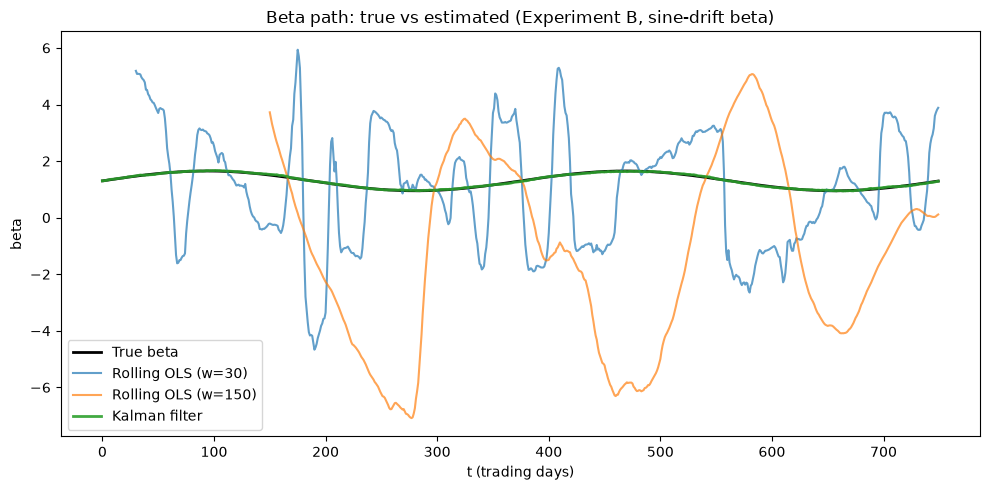

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_b["beta_true"], label="True beta", color="black", linewidth=2)
ax.plot(beta_roll_short, label="Rolling OLS (w=30)", alpha=0.7)
ax.plot(beta_roll_long, label="Rolling OLS (w=150)", alpha=0.7)
ax.plot(beta_kalman, label="Kalman filter", alpha=0.9, linewidth=2)
ax.set_xlabel("t (trading days)")
ax.set_ylabel("beta")
ax.set_title("Beta path: true vs estimated (Experiment B, sine-drift beta)")
ax.legend()
plt.tight_layout()
plt.savefig("beta_ladder_comparison.png", dpi=110)
plt.show()


## สรุป

ตัวเลข RMSE จากเซลล์ข้างบนคือ **หลักฐานที่ reproduce ได้** ของสิ่งที่ Part I เคลม — แต่กราฟด้านบนมีสิ่งที่ต้องพูดตรง ๆ เพิ่ม:

**⚠️ Rolling OLS ในกราฟแกว่งแรงกว่าที่คาดมาก** (พุ่งไปถึง ±6 ทั้งที่ β จริงอยู่แค่ช่วง ~0.95–1.65) — สาเหตุไม่ใช่แค่ "หน้าต่างสั้นจะกระตุก" ตามที่ Part I §1.6 พูดไว้กว้าง ๆ แต่ลึกกว่านั้น: **B_obs เป็น near-random-walk** (แทบไม่ขยับสุทธิในบางช่วง 30–150 วัน) → ตัวหาร Var(x) ในสูตร OLS เล็กและสั่นเอง → สโลป (β̂) ยิ่งไวต่อ noise เป็นพิเศษจนแกว่งเกินจริง — นี่คือ**กับดักที่ปฏิบัติจริง**ของการทำ rolling regression บนราคาตรง ๆ (ไม่ใช่แค่ทฤษฎี) และเป็นอีกเหตุผลที่เดสก์ควอนต์เลี่ยง naive rolling-OLS บนราคา แล้วหันไปใช้ state-space method ที่มี "prior ความนุ่มนวล" (Q) กำกับไว้แทน — ตรงนี้แหละที่ Kalman ชนะขาดในกราฟ ไม่ใช่แค่เพราะ "จำอดีตดีกว่า" แต่เพราะ Q ที่เราตั้งไว้ทำหน้าที่ห้ามไม่ให้ β̂ กระโดดเกินจริงแบบที่ rolling ทำ
- Kalman ชนะขาดในรันนี้ (RMSE≈0.014 — เล็กกว่า rolling ที่ดีที่สุดกว่า 140 เท่า) **แต่ต้องเตือนตรง ๆ:** ตัวเลขนี้ดีเกินจริงที่จะคาดหวังในตลาดจริง เพราะ Q ที่ตั้งไว้ (`1e-4`) *บังเอิญ*ใกล้เคียงอัตราการเปลี่ยนจริงของ β จำลองชุดนี้พอดี — Kalman ไม่ได้ "ฉลาดเอง" มันดีเพราะเราป้อน Q ที่ถูกต้องให้ ลองเปลี่ยน Q เป็น `1e-8` (เชื่ออดีตมากไป) หรือ `1e-1` (เชื่อข้อมูลใหม่มากไป) แล้วรันใหม่ จะเห็น RMSE แย่ลงทันที — นี่คือเหตุผลที่ **Part IV ทั้ง Part** ทุ่มให้กับคำถามเดียว: "จะรู้ Q ที่ถูกต้องได้ยังไง โดยไม่แอบดูคำตอบ (β จริง) แบบที่ทำในสาธิตนี้"

⚠️ ตัวเลข RMSE ที่ได้เป็นค่าเฉพาะของข้อมูลจำลองชุดนี้ (seed=123) — ไม่ใช่ตัวเลขสากลที่จะเจอในทุกตลาด เปลี่ยน seed / พารามิเตอร์แล้วรันซ้ำเพื่อดูว่าข้อสรุปเชิงคุณภาพ (ลำดับ: Kalman ที่ tune ดี ≤ rolling ที่ดีที่สุด) เสถียรไหม
